# VAE Sanity Checks — Training on Synthetic Data
 
The interactive version of the VAE convergence study on synthetic waveforms.
Server-equivalent script is `VAE_sanity_checks_TrainOnSyntheticData.py`.

### Workflow
1. Load and concatenate synthetic waveform `.npz` files from `../synthetic_waveforms/`.
2. Preprocess waveforms (slicing, selection of true pulses by integral quantile).
3. Build a controlled-mixing dataset: each batch contains a fixed number of
   signal waveforms and noise-only waveforms, in a reproducible order.
4. Train one independent VAE instance per seed. For each seed:
   - initialise a new VAE with the given random seed
   - save the initial weights to `./weights/`
   - train for a fixed number of epochs
   - save the trained weights to `./weights/`
   - stream the training history to `./history_files/`

### Input
    ../synthetic_waveforms/synthetic_waveforms_00.npz
    ...
    ../synthetic_waveforms/synthetic_waveforms_09.npz

### Output
    ./history_files/{config_name}_{seed}.csv     training history per seed
    ./weights/{config_name}_{seed}_init.npz      weights before training
    ./weights/{config_name}_{seed}_trained.npz   weights after training

### Dependencies
`vae_model.py`, `waveforms_tools.py`, `weights_tools.py`

### Notes
- This notebook is a direct equivalent of `VAE_sanity_checks_TrainOnSyntheticData.py`.
  Any logic change must be applied to both files manually until a shared module is introduced.
- `shuffle=False` in `model.fit()` is intentional: the dataset is pre-mixed with a
  controlled signal/noise ratio per batch, and reproducibility requires that
  the batch structure is preserved across runs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

import keras
import tensorflow as tf
from tensorflow.keras import optimizers
from tensorflow.keras import callbacks

2026-03-24 12:00:45.904775: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-24 12:00:45.904843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-24 12:00:45.905745: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-24 12:00:45.911973: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-24 12:00:46.666030: W tensorflow/compiler/tf2

In [2]:
########################
##### Load dataset #####

data_dir = "../synthetic_waveforms"

data_title = f"{data_dir}/synthetic_waveforms_00.npz"
print(f"Opening file {data_title}")
loaded = np.load(data_title)

noise_wave = loaded['noise']
signal_wave = loaded['signal']
true_peaks = loaded['peak']
true_peak_positions = loaded['peak_position']
true_integrals = loaded['integral']

for i in range(1,10):
    data_title = f"{data_dir}/synthetic_waveforms_0{i}.npz"
    print(f"Opening file {data_title}")
    loaded = np.load(data_title)
    
    noise_wave = np.concatenate((noise_wave,loaded['noise']),axis=0)
    signal_wave = np.concatenate((signal_wave,loaded['signal']),axis=0)
    true_peaks = np.concatenate((true_peaks,loaded['peak']),axis=0)
    true_peak_positions = np.concatenate((true_peak_positions,loaded['peak_position']),axis=0)
    true_integrals = np.concatenate((true_integrals,loaded['integral']),axis=0)

wave = noise_wave + signal_wave

Opening file ../synthetic_waveforms/synthetic_waveforms_00.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_01.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_02.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_03.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_04.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_05.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_06.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_07.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_08.npz
Opening file ../synthetic_waveforms/synthetic_waveforms_09.npz


In [3]:
###############################
##### Dataset Preparation #####

from waveforms_tools import *

## remove time samples from the beginning and ending of each WF as done in real ReD data
wfs        =       wave[:,125:-22-125]
noise_wave = noise_wave[:,125:-22-125]

### fix original_dimension varible as the n. time samples in each event
original_dimension = wfs.shape[1]

# Get basic properties for all WFs
integrals  = get_integral(wfs, whole=True)
peaks      = get_peak(wfs)
sel_integral_indexes = get_quantile_indices(integrals)
sel_peak_indexes     = get_quantile_indices(peaks)

## Apply a threshold selection on the integral 
good_wfs = wfs[sel_integral_indexes]

print(f'Selecting {len(good_wfs)} events considered as true pulses')

true_pulses = np.expand_dims(good_wfs, axis=-1)
pure_noise  = np.expand_dims(noise_wave, axis=-1)
print(true_pulses.shape)
print(pure_noise.shape)

Selecting 1000 events considered as true pulses
(1000, 9728, 1)
(10000, 9728, 1)


In [ ]:
##########################
##### Dataset Mixing #####

# Configuration
batch_size = 100
total_batches = 70
n_good_evts_per_batch = 10

assert n_good_evts_per_batch < batch_size, "Requested too many good waveforms per batch."

config_name = f'VAE_4dim_bis_{total_batches*batch_size}evts_{n_good_evts_per_batch}good-per-batch'

### To make sure that the mixed dataset have 
### the events in the same order
rng = np.random.default_rng(seed=42) 

dataset = []

# Configuration
n_random = batch_size - n_good_evts_per_batch
final_size = total_batches * batch_size

# --- Validation ---
assert true_pulses.shape[0] >= total_batches * n_good_evts_per_batch, "Not enough unique waveforms in true pulses."

# --- Step 1: Random sampling ---
# Select the required number of unique good waveforms
good_indices = rng.permutation(true_pulses.shape[0])[:total_batches * n_good_evts_per_batch]
good_waveforms = true_pulses[good_indices]  # Shape: (n. good, 9728, 1)

# Select the required number of random traces (with replacement) from pure_noise
random_indices = rng.choice(pure_noise.shape[0], size=total_batches * n_random, replace=True)
random_waveforms = pure_noise[random_indices]  # Shape: (n. random, 9728, 1)

# Step 2: Interleave exactly 10 good + 90 noise per batch
good_waveforms = good_waveforms.reshape(total_batches, n_good_evts_per_batch, *good_waveforms.shape[1:])
random_waveforms = random_waveforms.reshape(total_batches, n_random, *random_waveforms.shape[1:])

# Combine per batch
batched = np.concatenate([good_waveforms, random_waveforms], axis=1)  

# --- Step 3: Shuffle each batch independently (no loop) ---
shuffle_indices = np.argsort(rng.random((total_batches, batch_size)), axis=1)
shuffled = batched[np.arange(total_batches)[:, None], shuffle_indices]

# --- Step 4: Flatten back to final output ---
dataset = shuffled.reshape(final_size, *batched.shape[2:])  # (n. tot, 9728, 1)
    

In [5]:
#########################
##### Train the VAE #####

from vae_model import VAE, build_encoder, build_decoder
from weights_tools import *

os.makedirs("./history_files", exist_ok=True)

# Parameters of the architecture

# Latent Dimension
latent_dim = 4

# n. of filters
n_filters = [2, 4, 8]

# Seeds for obtaining different models' training
seeds = np.array([32467, 75410, 87278, 34987, 38956, 26012, 67418, 47842, 66012, 87346])

print(f"Dataset name : {config_name}")
print(f"Dataset shape: {dataset.shape}")
print(f'{n_good_evts_per_batch} good events in each batch of {batch_size} events.') 
    
for j in range (0,int(seeds.size)):

    print(f"\nInitializing model {j} (seed {seeds[j]})")

    keras.utils.set_random_seed(int(seeds[j]))
    tf.keras.utils.set_random_seed(int(seeds[j]))

    # Stream history into a CSV file
    csv_logger = callbacks.CSVLogger(f'./history_files/{config_name}_{seeds[j]}.csv', 
                                     separator=',', append=False)

    vae = VAE(build_encoder(original_dimension, latent_dim, n_filters), 
              build_decoder(original_dimension, latent_dim, n_filters))
    vae.compile(optimizer=optimizers.Adam(learning_rate=1e-3))

    save_weights_npz(vae, config_name, "init", seeds[j], overwrite=True)

    vae.fit(dataset, epochs=15, validation_split=0.2, shuffle=False,
            batch_size=batch_size, callbacks=[csv_logger], verbose=2)

    save_weights_npz(vae, config_name, "trained", seeds[j], overwrite=True)


Dataset name : VAE_4dim_7000evts_10good-per-batch
Dataset shape: (7000, 9728, 1)
10 good events in each batch of 100 events.

Initializing model 0 (seed 32467)


2026-03-24 12:00:52.901591: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-24 12:00:52.930953: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-24 12:00:52.932736: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-


[npz saved] → ./weights/VAE_4dim_7000evts_10good-per-batch_32467_init.npz  
keys: ['encoder__conv1__kernel', 'encoder__conv1__bias', 'encoder__conv2__kernel', 'encoder__conv2__bias', 'encoder__conv3__kernel', 'encoder__conv3__bias', 'encoder__z_mean__kernel', 'encoder__z_mean__bias', 'encoder__z_log_var__kernel', 'encoder__z_log_var__bias', 'decoder__dense_decoded__kernel', 'decoder__dense_decoded__bias', 'decoder__deconv3__kernel', 'decoder__deconv3__bias', 'decoder__deconv2__kernel', 'decoder__deconv2__bias', 'decoder__deconv1__kernel', 'decoder__deconv1__bias']

Epoch 1/15


2026-03-24 12:01:10.289511: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-03-24 12:01:10.357971: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-24 12:01:10.515391: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-24 12:01:11.091223: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f41316cdbb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-24 12:01:11.091268: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-PCIE-40GB, Compute Capability 8.0
2026-03-24 12:01:11.096591: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774353671.186633  122045 device_compiler.h:

56/56 - 21s - loss: 3135.9583 - reconstruction_loss: 2960.2468 - kl_loss: 175.7100 - val_loss: 54.4043 - val_reconstruction_loss: 14.2886 - val_kl_loss: 40.1157 - 21s/epoch - 383ms/step
Epoch 2/15
56/56 - 2s - loss: 38.8995 - reconstruction_loss: 10.6805 - kl_loss: 28.2190 - val_loss: 31.1475 - val_reconstruction_loss: 10.2114 - val_kl_loss: 20.9361 - 2s/epoch - 31ms/step
Epoch 3/15
56/56 - 2s - loss: 24.9562 - reconstruction_loss: 8.1580 - kl_loss: 16.7982 - val_loss: 20.3595 - val_reconstruction_loss: 8.0866 - val_kl_loss: 12.2728 - 2s/epoch - 31ms/step
Epoch 4/15
56/56 - 2s - loss: 17.3616 - reconstruction_loss: 7.8183 - kl_loss: 9.5433 - val_loss: 15.3199 - val_reconstruction_loss: 7.8987 - val_kl_loss: 7.4212 - 2s/epoch - 31ms/step
Epoch 5/15
56/56 - 2s - loss: 13.8966 - reconstruction_loss: 7.6990 - kl_loss: 6.1976 - val_loss: 12.7909 - val_reconstruction_loss: 7.6824 - val_kl_loss: 5.1084 - 2s/epoch - 31ms/step
Epoch 6/15
56/56 - 2s - loss: 11.9249 - reconstruction_loss: 7.5493 

## Results
Visual inspection of the training histories and weight distributions.

A subset of the training seeds can be explicitly defined to reduce number of plots/comparisons.

In [6]:
###########################################
##### Example plots of stored weights #####

from weights_tools import *

dataset_name = "VAE_4dim_7000evts_10good-per-batch"
#seeds = np.array([32467, 75410, 26012])


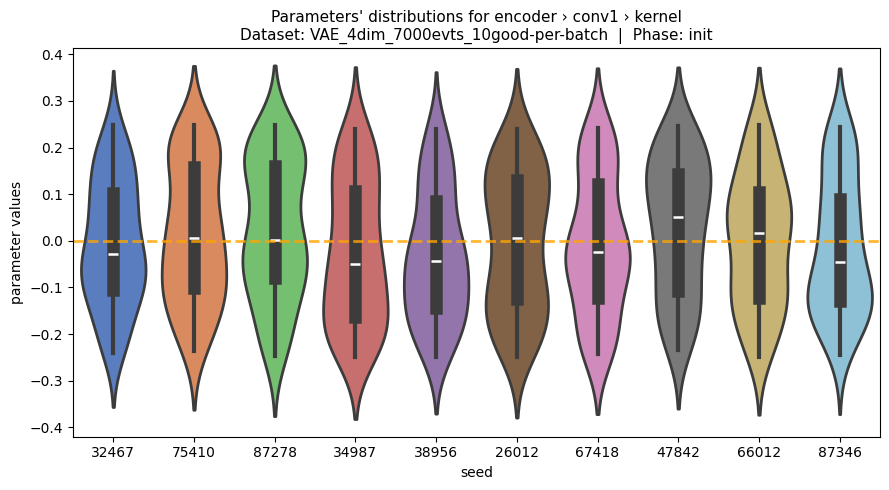

  [plot saved] → ./plots/violin_VAE_4dim_7000evts_10good-per-batch_init_encoder_conv1_kernel.png


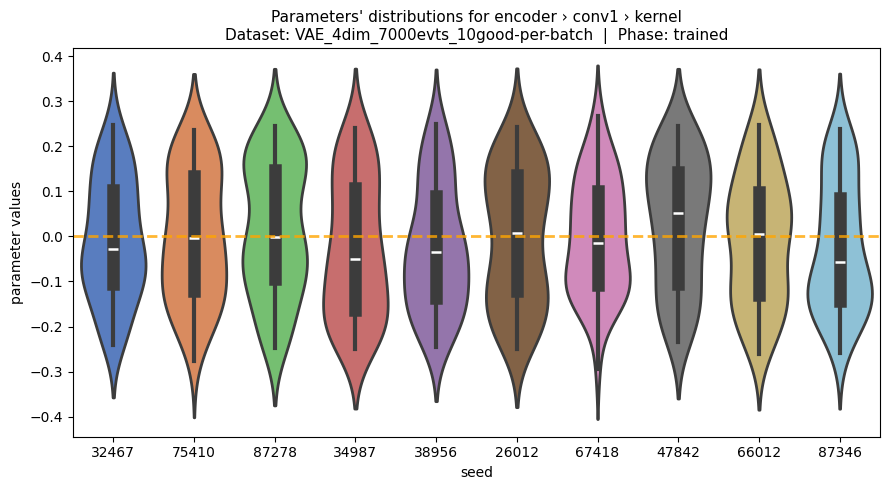

  [plot saved] → ./plots/violin_VAE_4dim_7000evts_10good-per-batch_trained_encoder_conv1_kernel.png


In [7]:
plot_violins(dataset_name, seeds, phase="init", 
             submodel="encoder", layer="conv1", weight_type="kernel")

plot_violins(dataset_name, seeds, phase="trained", 
             submodel="encoder", layer="conv1", weight_type="kernel")

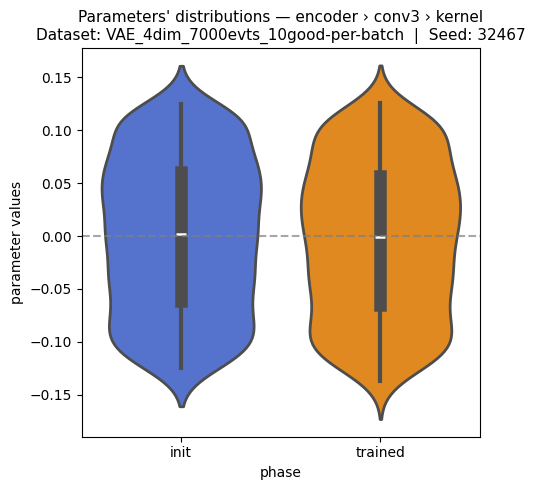

  [plot saved] → ./plots/violin_comparison_VAE_4dim_7000evts_10good-per-batch_32467_encoder_conv3_kernel.png


In [8]:
# Violin plot: init vs trained for a single seed
plot_violin_comparison(dataset_name, seed=seeds[0], 
                       submodel="encoder", layer="conv3", weight_type="kernel")

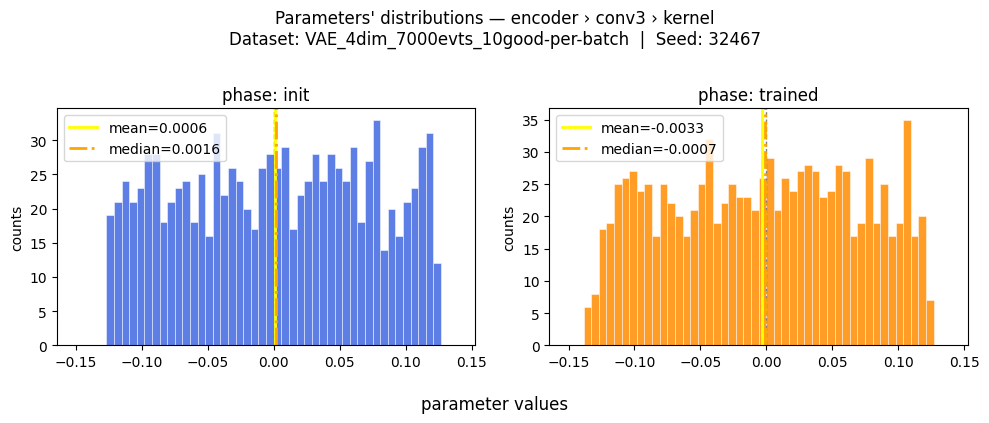

  [plot saved] → ./plots/hist_comparison_VAE_4dim_7000evts_10good-per-batch_32467_encoder_conv3_kernel.png


In [9]:
# Histograms: init vs trained for a single seed
plot_histograms_comparison(dataset_name, seed=seeds[0], 
                           submodel="encoder", layer="conv3", weight_type="kernel")

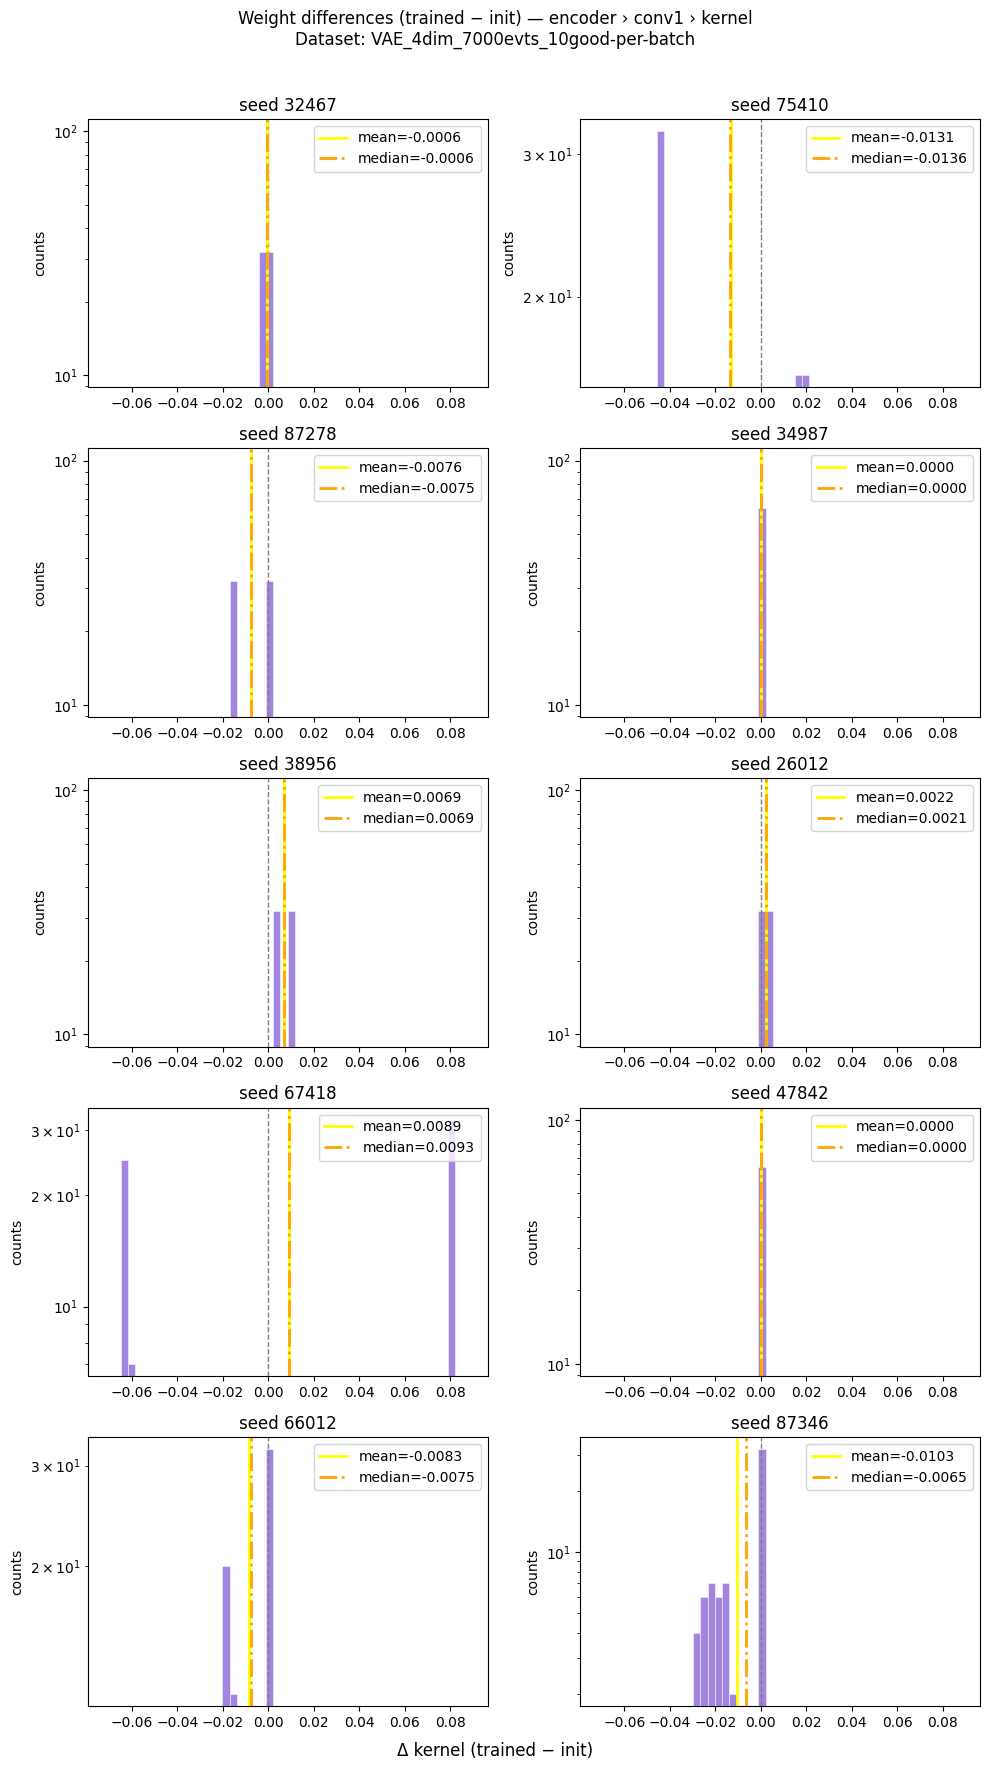

  [plot saved] → ./plots/hist_deltas_VAE_4dim_7000evts_10good-per-batch_encoder_conv1_kernel.png


In [10]:
# Plot histogram of the weights differences at different training phases
plot_histograms_deltas(dataset_name, seeds, 
                       submodel="encoder", layer="conv1", weight_type="kernel")